In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [68]:
df = pd.read_csv("../synthetic_transactions.csv")

df.head()

,transaction_id,user_id,timestamp,amount,merchant_category,transaction_type,location,device_type,device_id,old_balance,new_balance,account_age_days,daily_transaction_count,fraud_label,fraud_type,time_since_last_transaction,is_foreign_transaction
0,TXN_ae90f24c32,USER_0001,2026-05-14 16:03:34.263585,1623.40,GROCERY,CARD,Mumbai,Android,DEV_a7fb1a55,753982.76,752359.36,1737,0,0,NaN,NaN,NaN
1,TXN_a5995e7bf0,USER_0002,2026-05-14 23:28:23.263628,10646.33,SHOPPING,CARD,Kolkata,Web,DEV_69f704db,112997.21,102350.88,2978,0,0,NaN,NaN,NaN
2,TXN_0cb2860c6f,USER_0003,2026-05-14 15:06:17.263652,552.37,SHOPPING,WALLET,Delhi,iPhone,DEV_d4688355,13715.05,13162.68,2971,0,0,NaN,NaN,NaN
3,TXN_d4d849a596,USER_0004,2026-05-14 21:43:52.263672,4544.45,TRAVEL,BANK_TRANSFER,Delhi,Android,DEV_e0882e6a,36734.98,32190.53,3777,0,0,NaN,NaN,NaN
4,TXN_27c4859ba5,USER_0005,2026-05-14 20:57:33.263686,2818.30,TRAVEL,WALLET,Mumbai,iPhone,DEV_a83913f3,101114.22,98295.92,681,0,0,NaN,NaN,NaN


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transaction_id               10000 non-null  object 
 1   user_id                      10000 non-null  object 
 2   timestamp                    10000 non-null  object 
 3   amount                       10000 non-null  float64
 4   merchant_category            10000 non-null  object 
 5   transaction_type             10000 non-null  object 
 6   location                     10000 non-null  object 
 7   device_type                  10000 non-null  object 
 8   device_id                    10000 non-null  object 
 9   old_balance                  10000 non-null  float64
 10  new_balance                  10000 non-null  float64
 11  account_age_days             10000 non-null  int64  
 12  daily_transaction_count      10000 non-null  int64  
 13  fraud_label      

In [70]:
df["fraud_label"].value_counts()


fraud_label
0    9790
1     210
Name: count, dtype: int64

In [71]:
fraud_percentage = (df["fraud_label"].mean()) * 100
print(f"Fraud Percentage: {fraud_percentage:.2f}%")

Fraud Percentage: 2.10%


In [72]:
df["amount"].describe()

count    1.000000e+04
mean     1.825855e+04
std      8.458108e+04
min      1.500000e+00
25%      9.501450e+02
50%      2.388040e+03
75%      6.099347e+03
max      4.254366e+06
Name: amount, dtype: float64

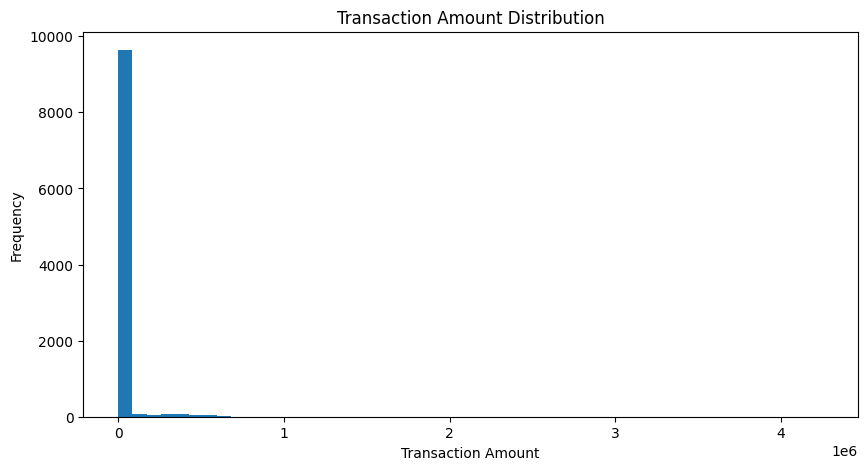

In [73]:
plt.figure(figsize=(10, 5))
plt.hist(df["amount"], bins=50)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.show()

amount to balance ratio for high draining behaviour

In [74]:
df["amount_balance_ratio"] = (df["amount"] / (df["old_balance"] + 1))
df[[ "amount",
    "old_balance",
    "amount_balance_ratio"
]].head()

,amount,old_balance,amount_balance_ratio
0,1623.40,753982.76,0.002153
1,10646.33,112997.21,0.094217
2,552.37,13715.05,0.040272
3,4544.45,36734.98,0.123706
4,2818.30,101114.22,0.027872


abnormal spending


In [75]:
high_amount_threshold = (
    df["amount"].quantile(0.95)
)

df["is_high_amount"] = (
    df["amount"] > high_amount_threshold
).astype(int)

df[[
    "amount",
    "is_high_amount"
]].head()

,amount,is_high_amount
0,1623.40,0
1,10646.33,0
2,552.37,0
3,4544.45,0
4,2818.30,0


suspicious timings

In [76]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

df["transaction_hour"] = (
    df["timestamp"].dt.hour
)

df[[
    "timestamp",
    "transaction_hour"
]].head()

,timestamp,transaction_hour
0,2026-05-14 16:03:34.263585,16
1,2026-05-14 23:28:23.263628,23
2,2026-05-14 15:06:17.263652,15
3,2026-05-14 21:43:52.263672,21
4,2026-05-14 20:57:33.263686,20


In [77]:
df["is_night_transaction"] = (
    (df["transaction_hour"] >= 0)  &  (df["transaction_hour"] <= 5)
).astype(int)

df[[
    "transaction_hour",
    "is_night_transaction"
]].head()

,transaction_hour,is_night_transaction
0,16,0
1,23,0
2,15,0
3,21,0
4,20,0


location anomaly

In [78]:
df["is_foreign_transaction"] = (
    df["is_foreign_transaction"]
    .fillna(0)
)

df["is_foreign_transaction"].value_counts()

is_foreign_transaction
0.0    9949
1.0      51
Name: count, dtype: int64

device change


In [79]:
previous_device = ( df.groupby("user_id")["device_id"].shift(1))
df["device_change"] = (( df["device_id"] != previous_device ) & previous_device.notna()).astype(int)
df[[
    "user_id",
    "device_id",
    "device_change"
]].head(20)

,user_id,device_id,device_change
0,USER_0001,DEV_a7fb1a55,0
1,USER_0002,DEV_69f704db,0
2,USER_0003,DEV_d4688355,0
3,USER_0004,DEV_e0882e6a,0
4,USER_0005,DEV_a83913f3,0
5,USER_0006,DEV_0fc35bab,0
6,USER_0007,DEV_13f456f4,0
7,USER_0008,DEV_5ca35b26,0
8,USER_0009,DEV_df077dd0,0
9,USER_0010,DEV_021c4f51,0


velocity fraud

In [80]:
df = df.sort_values(
    by=["user_id", "timestamp"]
)

In [81]:
df["previous_transaction_time"] = (
    df.groupby("user_id")["timestamp"]
    .shift(1)
)

In [82]:
df["transaction_gap_seconds"] = (( df["timestamp"] - df["previous_transaction_time"]).dt.total_seconds())

df[[
    "user_id",
    "timestamp",
    "previous_transaction_time",
    "transaction_gap_seconds"
]].head(20)

,user_id,timestamp,previous_transaction_time,transaction_gap_seconds
800,USER_0001,2026-05-14 07:01:12.276391,NaT,NaN
3200,USER_0001,2026-05-14 07:15:53.297293,2026-05-14 07:01:12.276391,881.020902
6900,USER_0001,2026-05-14 07:33:25.326143,2026-05-14 07:15:53.297293,1052.028850
9900,USER_0001,2026-05-14 07:36:48.349438,2026-05-14 07:33:25.326143,203.023295
3800,USER_0001,2026-05-14 07:39:51.301912,2026-05-14 07:36:48.349438,182.952474
7400,USER_0001,2026-05-14 07:47:13.329960,2026-05-14 07:39:51.301912,442.028048
4100,USER_0001,2026-05-14 08:04:53.304284,2026-05-14 07:47:13.329960,1059.974324
4000,USER_0001,2026-05-14 08:46:01.303460,2026-05-14 08:04:53.304284,2467.999176
5500,USER_0001,2026-05-14 09:03:12.315115,2026-05-14 08:46:01.303460,1031.011655
7900,USER_0001,2026-05-14 09:15:24.333916,2026-05-14 09:03:12.315115,732.018801


In [83]:
df["rapid_transaction"] = (
    df["transaction_gap_seconds"] < 60
).astype(int)

df[[
    "transaction_gap_seconds",
    "rapid_transaction"
]].head(20)

,transaction_gap_seconds,rapid_transaction
800,NaN,0
3200,881.020902,0
6900,1052.028850,0
9900,203.023295,0
3800,182.952474,0
7400,442.028048,0
4100,1059.974324,0
4000,2467.999176,0
5500,1031.011655,0
7900,732.018801,0


rolling transactions

In [84]:
df["rapid_transaction"].value_counts()

rapid_transaction
0    9076
1     924
Name: count, dtype: int64

In [85]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

In [86]:
df = df.sort_values(
    by=["user_id", "timestamp"]
)

In [87]:
df = df.set_index("timestamp")

In [88]:
df["transactions_last_5min"] = (
    df.groupby("user_id")
      .rolling("5min")["amount"]
      .count()
      .reset_index(level=0, drop=True)
)

In [89]:
df = df.reset_index()

In [90]:
df[[
    "user_id",
    "timestamp",
    "transactions_last_5min"
]].head(30)

,user_id,timestamp,transactions_last_5min
0,USER_0001,2026-05-14 07:01:12.276391,1.0
1,USER_0001,2026-05-14 07:15:53.297293,1.0
2,USER_0001,2026-05-14 07:33:25.326143,1.0
3,USER_0001,2026-05-14 07:36:48.349438,2.0
4,USER_0001,2026-05-14 07:39:51.301912,2.0
5,USER_0001,2026-05-14 07:47:13.329960,1.0
6,USER_0001,2026-05-14 08:04:53.304284,1.0
7,USER_0001,2026-05-14 08:46:01.303460,1.0
8,USER_0001,2026-05-14 09:03:12.315115,1.0
9,USER_0001,2026-05-14 09:15:24.333916,1.0


In [91]:
from sklearn.preprocessing import LabelEncoder

In [92]:
categorical_columns = [
    "merchant_category",
    "transaction_type",
    "location",
    "device_type",
    "fraud_type"
]

In [93]:
encoders = {}
for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform( df[column].astype(str))
    encoders[column] = encoder

In [94]:
df.head()

,timestamp,transaction_id,user_id,amount,merchant_category,transaction_type,location,device_type,device_id,old_balance,...,is_foreign_transaction,amount_balance_ratio,is_high_amount,transaction_hour,is_night_transaction,device_change,previous_transaction_time,transaction_gap_seconds,rapid_transaction,transactions_last_5min
0,2026-05-14 07:01:12.276391,TXN_04dce4361c,USER_0001,1844.00,0,2,7,0,DEV_aec95562,741940.71,...,0.0,0.002485,0,7,0,1,NaT,NaN,0,1.0
1,2026-05-14 07:15:53.297293,TXN_fc827bb3e1,USER_0001,1072.92,5,4,7,0,DEV_aec95562,704074.81,...,0.0,0.001524,0,7,0,0,2026-05-14 07:01:12.276391,881.020902,0,1.0
2,2026-05-14 07:33:25.326143,TXN_040e578634,USER_0001,1043.95,5,3,7,0,DEV_aec95562,644210.93,...,0.0,0.001621,0,7,0,1,2026-05-14 07:15:53.297293,1052.028850,0,1.0
3,2026-05-14 07:36:48.349438,TXN_93f0462305,USER_0001,1139.98,8,3,7,0,DEV_aec95562,597958.29,...,0.0,0.001906,0,7,0,0,2026-05-14 07:33:25.326143,203.023295,0,2.0
4,2026-05-14 07:39:51.301912,TXN_077a7e0188,USER_0001,2180.08,5,3,7,0,DEV_a7fb1a55,695296.65,...,0.0,0.003135,0,7,0,0,2026-05-14 07:36:48.349438,182.952474,0,2.0


In [95]:
df.isnull().sum()

timestamp                         0
transaction_id                    0
user_id                           0
amount                            0
merchant_category                 0
transaction_type                  0
location                          0
device_type                       0
device_id                         0
old_balance                       0
new_balance                       0
account_age_days                  0
daily_transaction_count           0
fraud_label                       0
fraud_type                        0
time_since_last_transaction    9962
is_foreign_transaction            0
amount_balance_ratio              0
is_high_amount                    0
transaction_hour                  0
is_night_transaction              0
device_change                     0
previous_transaction_time       100
transaction_gap_seconds         100
rapid_transaction                 0
transactions_last_5min            0
dtype: int64

In [96]:
df = df.fillna(0)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    10000 non-null  datetime64[ns]
 1   transaction_id               10000 non-null  object        
 2   user_id                      10000 non-null  object        
 3   amount                       10000 non-null  float64       
 4   merchant_category            10000 non-null  int64         
 5   transaction_type             10000 non-null  int64         
 6   location                     10000 non-null  int64         
 7   device_type                  10000 non-null  int64         
 8   device_id                    10000 non-null  object        
 9   old_balance                  10000 non-null  float64       
 10  new_balance                  10000 non-null  float64       
 11  account_age_days             10000 non-nul

In [98]:
df.to_csv(
    "../processed_transactions.csv",
    index=False
)

Model making

In [99]:
X = df.drop(columns = ["fraud_label","transaction_id","device_id","previous_transaction_time","timestamp","user_id","fraud_type"])
y = df["fraud_label"]

In [100]:
X.shape,y.shape

((10000, 19), (10000,))

In [101]:
from sklearn.model_selection import train_test_split

we use stratify here because fraud cases are negligible so in test split there is a chance that there wont be any fraud cases so our model wont be having a good test dataset so we need deliberately some dataset into the test split so as to see how our model works efficiently

In [102]:
X_train,X_test,y_train,y_test =   train_test_split(X,y,test_size =0.2,random_state=42,stratify=y)  

In [103]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((8000, 19), (2000, 19), (8000,), (2000,))

In [104]:
from sklearn.ensemble import RandomForestClassifier


In [105]:
model = RandomForestClassifier(n_estimators = 100,random_state = 42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [106]:
y_pred = model.predict(X_test)

In [107]:
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix)

In [108]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1 Score:",
      f1_score(y_test, y_pred))

Accuracy: 0.9925
Precision: 1.0
Recall: 0.6428571428571429
F1 Score: 0.782608695652174


In [109]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1958
           1       1.00      0.64      0.78        42

    accuracy                           0.99      2000
   macro avg       1.00      0.82      0.89      2000
weighted avg       0.99      0.99      0.99      2000



here precision is 1.0 which says when our model predicts fraud this surely states that yes the given case is fraud but we can see our recall is 0.64 which says it actually misses some fraud cases our model is trying to avoid aggresive calls and prefering over high precision but we need more recall as identifying a normal dataset fraud is much better than identifying a fraud dataset as normal

In [110]:
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[1958    0]
 [  15   27]]


identifying feature importance 

In [111]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_
})

In [112]:
feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)
feature_importance.head(10)

,Feature,Importance
0,amount,0.219463
10,is_foreign_transaction,0.191283
9,time_since_last_transaction,0.154015
11,amount_balance_ratio,0.099871
3,location,0.055277
8,daily_transaction_count,0.051083
6,new_balance,0.048638
5,old_balance,0.039607
16,transaction_gap_seconds,0.033010
1,merchant_category,0.025958


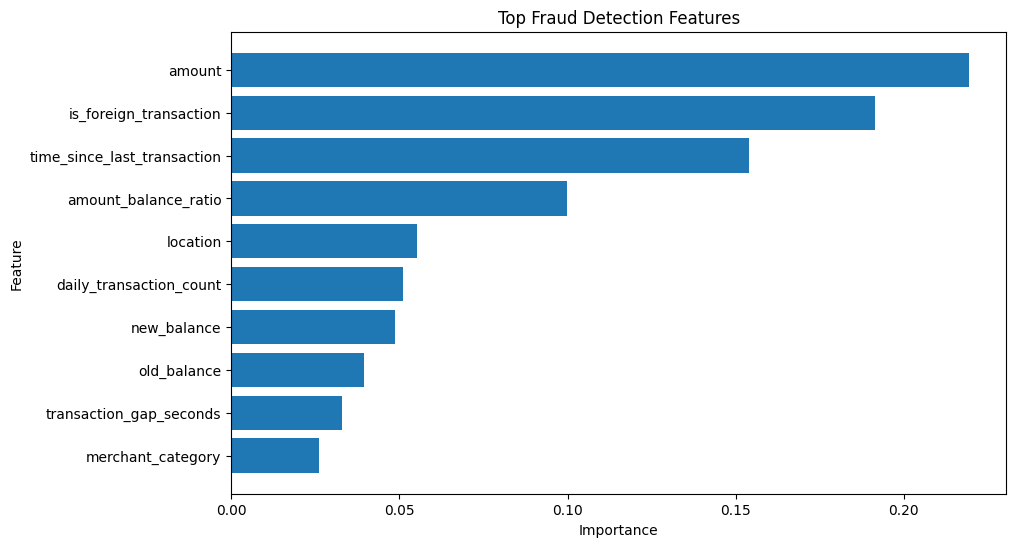

In [113]:
plt.figure(figsize=(10, 6))

plt.barh(

    feature_importance["Feature"][:10],

    feature_importance["Importance"][:10]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top Fraud Detection Features")

plt.gca().invert_yaxis()

plt.show()

we want to improve our recall without less tradeoff with precision so we have two options :- class weighing and SMOTE will start with class weighing we will give weights to frauds expressing them as expensive

In [114]:
weighted_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    class_weight="balanced"
)

weighted_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

here balance provides automatically more weight to minority class

In [115]:
weighted_pred = weighted_model.predict(X_test)

In [116]:
print(
    classification_report(
        y_test,
        weighted_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1958
           1       1.00      0.67      0.80        42

    accuracy                           0.99      2000
   macro avg       1.00      0.83      0.90      2000
weighted avg       0.99      0.99      0.99      2000



recall improved from 0.64 to 0.67

now we apply SMOTE creating synthetic fraud examples so that model learns better about the fraud examples and do pattern recognition in order to predict fraud appropriately it doesnt duplicate fraud rows 

In [117]:
from imblearn.over_sampling import SMOTE


applying SMOTE only on training data if we do before train-test split data leakage occurs

In [118]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train,
    y_train
)

In [119]:
y_train.value_counts(),y_train_smote.value_counts()

(fraud_label
 0    7832
 1     168
 Name: count, dtype: int64,
 fraud_label
 0    7832
 1    7832
 Name: count, dtype: int64)

In [120]:
smote_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

smote_model.fit(

    X_train_smote,
    y_train_smote
)

RandomForestClassifier(random_state=42)

In [121]:
smote_pred = smote_model.predict(
    X_test
)

In [122]:
print(
    classification_report(
        y_test,
        smote_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1958
           1       0.91      0.71      0.80        42

    accuracy                           0.99      2000
   macro avg       0.95      0.86      0.90      2000
weighted avg       0.99      0.99      0.99      2000



recall improved from 0.67 to 0.71

combined both class wighting and SMOTE

In [125]:
new_smote_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    class_weight= "balanced"
)

new_smote_model.fit(

    X_train_smote,
    y_train_smote
)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [126]:
new_smote_pred = new_smote_model.predict(X_test)

In [127]:
print(
    classification_report(
        y_test,
        new_smote_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1958
           1       0.91      0.71      0.80        42

    accuracy                           0.99      2000
   macro avg       0.95      0.86      0.90      2000
weighted avg       0.99      0.99      0.99      2000



didnt had any impact so now instead of data manipulation we can move forward to better nonlinear models the best we can see here is xgboost

In [128]:
from xgboost import XGBClassifier

In [129]:
xgb_model = XGBClassifier(n_estimators = 200,max_depth = 6,learning_rate = 0.05,subsample = 0.8,colsample_bytree = 0.8,random_state = 42,eval_metric = 'logloss')

In [130]:
xgb_model.fit(

    X_train_smote,

    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [131]:
xgb_pred = xgb_model.predict(
    X_test
)

In [132]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1958
           1       0.83      0.71      0.77        42

    accuracy                           0.99      2000
   macro avg       0.91      0.86      0.88      2000
weighted avg       0.99      0.99      0.99      2000



xgboost reduced precision means it catch more normal transaction as fraud but recall remain same hence here randomforest outperformed xgboost

tuning threshold probability

In [135]:
fraud_probabilities = (

    weighted_model
    .predict_proba(X_test)[:, 1]
)

In [134]:
import numpy as np

In [137]:
thresholds = [

    0.5,
    0.4,
    0.3,
    0.2,
    0.1
]

for threshold in thresholds:

    predictions = (
        fraud_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    print(f"\nThreshold: {threshold}")

    print(f"Precision: {precision:.2f}")

    print(f"Recall: {recall:.2f}")

    print(f"F1 Score: {f1:.2f}")


Threshold: 0.5
Precision: 1.00
Recall: 0.67
F1 Score: 0.80

Threshold: 0.4
Precision: 1.00
Recall: 0.67
F1 Score: 0.80

Threshold: 0.3
Precision: 1.00
Recall: 0.67
F1 Score: 0.80

Threshold: 0.2
Precision: 1.00
Recall: 0.74
F1 Score: 0.85

Threshold: 0.1
Precision: 0.82
Recall: 0.74
F1 Score: 0.78


we can see here for threshold probability 0.2 we got precision 0.74 and precision 1.0

In [138]:
final_probabilities = (

    weighted_model
    .predict_proba(X_test)[:, 1]
)

In [139]:
final_predictions = (

    final_probabilities >= 0.2
).astype(int)

In [140]:
print(
    classification_report(
        y_test,
        final_predictions
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1958
           1       1.00      0.74      0.85        42

    accuracy                           0.99      2000
   macro avg       1.00      0.87      0.92      2000
weighted avg       0.99      0.99      0.99      2000



In [141]:
best_threshold = 0.2